# LIIF-EQ Improved (GPU-preload + GPU aug) — v4

This notebook is the v4 you pasted, organized into notebook cells.

Before running:
- Update `CONFIG['hr_path']`, `CONFIG['lr_path']`, `CONFIG['pretrained_path']`.
- Install: `torch`, `numpy`, `matplotlib`, `tqdm`, `scikit-image`.


In [1]:
import os
import glob
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr


In [2]:
CONFIG = {
    # Dataset paths (UPDATE THESE)
    'hr_path': '/home/jovyan/work/pinn/super_resoltuion/dataset/Dataset/HR',
    'lr_path': '/home/jovyan/work/pinn/super_resoltuion/dataset/Dataset/LR',

    # Pretrained weights (optional)
    'pretrained_path': '/home/jovyan/work/pinn/super_resoltuion/liif_lensing_best.pth',

    # Training parameters (IMPROVED)
    'batch_size': 4,          # Smaller batch for better gradients
    'epochs': 200,            # More epochs
    'lr': 1e-4,               # Slightly higher initial LR
    'test_split': 0.1,
    'device': 'cuda',
    'seed': 42,
    'sample_q': 4096,         # More query points
    'num_workers': 0,

    # Architecture parameters (IMPROVED)
    'encoder_dim': 128,       # Increased from 64
    'n_resblocks': 24,        # Increased from 16
    'hidden_list': [1024, 512, 256, 256],  # Larger MLP
    'tranNum': 8,             # Increased from 4 (45° instead of 90°)
    'kernel_size': 5,
    'feat_unfold': True,      # Enable feature unfolding

    # Augmentation parameters
    'augment': True,
    'augment_factor': 16,     # Increased from 8

    # Regularization
    'weight_decay': 5e-5,     # Reduced
    'early_stop_patience': 25,
    'dropout': 0.1,           # Added dropout

    # Loss weights
    'l1_weight': 0.84,
    'ssim_weight': 0.16,
}

print(f"Using device: {CONFIG['device']}")
print(f"tranNum: {CONFIG['tranNum']} (every {360//CONFIG['tranNum']}°)")
print(f"Encoder dim: {CONFIG['encoder_dim']}, ResBlocks: {CONFIG['n_resblocks']}")
print(f"Feature unfold: {CONFIG['feat_unfold']}")
print(f"Augmentation: {CONFIG['augment']} (factor: {CONFIG['augment_factor']}x)")

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


Using device: cuda
tranNum: 8 (every 45°)
Encoder dim: 128, ResBlocks: 24
Feature unfold: True
Augmentation: True (factor: 16x)


In [3]:
class LensingDataset(Dataset):
    def __init__(self, hr_path, lr_path, augment=False):
        self.hr_files = sorted(glob.glob(os.path.join(hr_path, '*.npy')))
        self.lr_files = sorted(glob.glob(os.path.join(lr_path, '*.npy')))
        self.augment = augment

        print(f"Found {len(self.hr_files)} HR files")
        print(f"Found {len(self.lr_files)} LR files")

        def extract_id(filepath):
            basename = os.path.basename(filepath)
            name = os.path.splitext(basename)[0]
            parts = name.split('_')
            if len(parts) >= 2:
                return parts[-1]
            return name

        hr_dict = {extract_id(f): f for f in self.hr_files}
        lr_dict = {extract_id(f): f for f in self.lr_files}

        common_ids = set(hr_dict.keys()) & set(lr_dict.keys())
        common_ids = sorted(common_ids, key=lambda x: int(x) if x.isdigit() else x)

        self.hr_files = [hr_dict[id_] for id_ in common_ids]
        self.lr_files = [lr_dict[id_] for id_ in common_ids]

        print(f"Matched {len(self.hr_files)} HR-LR pairs")

    def __len__(self):
        return len(self.hr_files)

    def _apply_augmentation(self, lr, hr):
        # Random rotation (0, 90, 180, 270 degrees)
        k = np.random.randint(0, 4)
        if k > 0:
            lr = np.rot90(lr, k, axes=(-2, -1)).copy()
            hr = np.rot90(hr, k, axes=(-2, -1)).copy()

        # Random horizontal flip
        if np.random.random() > 0.5:
            lr = np.flip(lr, axis=-1).copy()
            hr = np.flip(hr, axis=-1).copy()

        # Random vertical flip
        if np.random.random() > 0.5:
            lr = np.flip(lr, axis=-2).copy()
            hr = np.flip(hr, axis=-2).copy()

        # Random intensity scaling
        if np.random.random() > 0.5:
            scale = np.random.uniform(0.9, 1.1)
            lr = np.clip(lr * scale, 0, 1)
            hr = np.clip(hr * scale, 0, 1)

        # Random Gaussian noise on LR
        if np.random.random() > 0.7:
            noise_std = np.random.uniform(0.001, 0.01)
            lr = lr + np.random.normal(0, noise_std, lr.shape).astype(np.float32)
            lr = np.clip(lr, 0, 1)

        return lr, hr

    def __getitem__(self, idx):
        hr = np.load(self.hr_files[idx]).astype(np.float32)
        lr = np.load(self.lr_files[idx]).astype(np.float32)

        if hr.ndim == 2:
            hr = hr[np.newaxis, ...]
        if lr.ndim == 2:
            lr = lr[np.newaxis, ...]

        # Normalize to [0, 1]
        hr = (hr - hr.min()) / (hr.max() - hr.min() + 1e-8)
        lr = (lr - lr.min()) / (lr.max() - lr.min() + 1e-8)

        if self.augment:
            lr, hr = self._apply_augmentation(lr, hr)

        hr = torch.from_numpy(hr.copy())
        lr = torch.from_numpy(lr.copy())

        return lr, hr


In [4]:
class LIIFEQDatasetGPU(Dataset):
    """GPU-preloaded dataset with GPU-based augmentation"""

    def __init__(self, base_dataset, sample_q=2304, tranNum=4, augment=False,
                 augment_factor=8, device='cuda'):
        self.sample_q = sample_q
        self.tranNum = tranNum
        self.augment = augment
        self.augment_factor = int(augment_factor) if augment else 1
        self.device = device

        print(f"Preloading {len(base_dataset)} samples to GPU...")

        self.data = []
        for i in tqdm(range(len(base_dataset)), desc="Loading to GPU"):
            lr, hr = base_dataset[i]
            self.data.append({'lr': lr.to(device), 'hr': hr.to(device)})

        self._coord_cache = {}
        self._cell_cache = {}

        if torch.cuda.is_available() and str(device).startswith('cuda'):
            mem_gb = torch.cuda.memory_allocated() / 1e9
            print(f"GPU memory used: {mem_gb:.2f} GB")

        print(f"Effective dataset size: {len(self)} samples")

    def __len__(self):
        return len(self.data) * self.augment_factor

    def _get_coord_cell(self, h, w):
        key = (h, w)
        if key not in self._coord_cache:
            coord_h = torch.linspace(-1 + 1/h, 1 - 1/h, h, device=self.device)
            coord_w = torch.linspace(-1 + 1/w, 1 - 1/w, w, device=self.device)
            coord = torch.stack(torch.meshgrid(coord_h, coord_w, indexing='ij'), dim=-1)
            coord = coord.view(-1, 2)

            cell = torch.ones(coord.shape[0], 2 * self.tranNum, device=self.device)
            cell[:, :self.tranNum] *= 2 / h
            cell[:, self.tranNum:] *= 2 / w

            self._coord_cache[key] = coord
            self._cell_cache[key] = cell

        return self._coord_cache[key], self._cell_cache[key]

    def _augment_gpu(self, lr, hr):
        # Random rotation (0, 90, 180, 270)
        k = torch.randint(0, 4, (1,), device=self.device).item()
        if k > 0:
            lr = torch.rot90(lr, k, dims=[-2, -1])
            hr = torch.rot90(hr, k, dims=[-2, -1])

        # Random flips
        if torch.rand(1, device=self.device).item() > 0.5:
            lr = torch.flip(lr, dims=[-1])
            hr = torch.flip(hr, dims=[-1])

        if torch.rand(1, device=self.device).item() > 0.5:
            lr = torch.flip(lr, dims=[-2])
            hr = torch.flip(hr, dims=[-2])

        # Random transpose
        if torch.rand(1, device=self.device).item() > 0.5:
            lr = lr.transpose(-2, -1)
            hr = hr.transpose(-2, -1)

        # Random intensity scaling
        if torch.rand(1, device=self.device).item() > 0.5:
            scale = 0.9 + torch.rand(1, device=self.device).item() * 0.2
            lr = torch.clamp(lr * scale, 0, 1)
            hr = torch.clamp(hr * scale, 0, 1)

        # Small noise on LR only
        if torch.rand(1, device=self.device).item() > 0.7:
            noise = torch.randn_like(lr) * 0.005
            lr = torch.clamp(lr + noise, 0, 1)

        return lr.contiguous(), hr.contiguous()

    def __getitem__(self, idx):
        real_idx = idx % len(self.data)
        item = self.data[real_idx]

        lr = item['lr']
        hr = item['hr']

        if self.augment:
            lr, hr = self._augment_gpu(lr, hr)

        h, w = hr.shape[-2:]
        coord, cell = self._get_coord_cell(h, w)

        gt = hr.reshape(hr.shape[0], -1).permute(1, 0)

        if self.sample_q is not None and self.sample_q < coord.shape[0]:
            sample_idx = torch.randperm(coord.shape[0], device=self.device)[:self.sample_q]
            coord = coord[sample_idx]
            cell = cell[sample_idx]
            gt = gt[sample_idx]

        return {'inp': lr, 'coord': coord, 'cell': cell, 'gt': gt}


def gpu_collate(batch):
    """Collate for data already on GPU"""
    return {
        'inp': torch.stack([b['inp'] for b in batch]),
        'coord': torch.stack([b['coord'] for b in batch]),
        'cell': torch.stack([b['cell'] for b in batch]),
        'gt': torch.stack([b['gt'] for b in batch]),
    }


In [5]:
def GetBasis_PCA(sizeP, tranNum=8, inP=None, Smooth=True):
    """Generate PCA basis for steerable convolutions"""
    if inP is None:
        inP = sizeP
    inp = inP // 2

    p = (sizeP - 1) / 2
    x = np.arange(-p, p + 1) / p
    X, Y = np.meshgrid(x, x)
    C = X**2 + Y**2

    if tranNum == 4:
        Mask = np.ones([sizeP, sizeP])
    else:
        if sizeP > 4:
            Mask = np.exp(-np.maximum(C - 1, 0) / 0.2)
        else:
            Mask = np.exp(-np.maximum(C - 1, 0) / 2)

    X0 = np.expand_dims(X, 2)
    Y0 = np.expand_dims(Y, 2)
    Mask = np.expand_dims(np.expand_dims(Mask, 2), 3)

    theta = np.arange(tranNum) / tranNum * 2 * np.pi
    theta = np.expand_dims(np.expand_dims(theta, axis=0), axis=0)

    Xr = np.cos(theta) * X0 - np.sin(theta) * Y0
    Yr = np.cos(theta) * Y0 + np.sin(theta) * X0

    Xr = Xr * inp
    Yr = Yr * inp

    Xr = np.expand_dims(np.expand_dims(Xr, 3), 4)
    Yr = np.expand_dims(np.expand_dims(Yr, 3), 4)

    k = np.reshape(np.arange(-inp, inp + 1), [1, 1, 1, inP, 1])
    l = np.reshape(np.arange(-inp, inp + 1), [1, 1, 1, 1, inP])

    def BicubicIni(x):
        absx = np.abs(x)
        absx2 = absx**2
        absx3 = absx**3
        Ind1 = (absx <= 1)
        Ind2 = (absx > 1) * (absx <= 2)
        return Ind1 * (1.5*absx3 - 2.5*absx2 + 1) + Ind2 * (-0.5*absx3 + 2.5*absx2 - 4*absx + 2)

    Basis = BicubicIni(Xr - k) * BicubicIni(Yr - l)
    Rank = inP * inP
    Basis = Basis.reshape([sizeP, sizeP, tranNum, Rank]) * Mask

    return torch.FloatTensor(Basis), Rank, 1


In [6]:
class Fconv_PCA(nn.Module):
    """Steerable PCA-based convolution for rotation equivariance"""

    def __init__(self, sizeP, inNum, outNum, tranNum=8, inP=None, padding=None,
                 ifIni=0, bias=True, Smooth=True, iniScale=1.0):
        super().__init__()

        if inP is None:
            inP = sizeP
        self.tranNum = tranNum
        self.outNum = outNum
        self.inNum = inNum
        self.sizeP = sizeP

        Basis, Rank, weight = GetBasis_PCA(sizeP, tranNum, inP, Smooth=Smooth)
        self.register_buffer("Basis", Basis)

        self.ifbias = bias
        self.expand = 1 if ifIni else tranNum

        self.weights = nn.Parameter(torch.Tensor(outNum, inNum, self.expand, Basis.size(3)), requires_grad=True)
        self.padding = 0 if padding is None else padding

        if bias:
            self.c = nn.Parameter(torch.Tensor(1, outNum, 1, 1))
        else:
            self.register_parameter('c', None)
        self.reset_parameters()

    def forward(self, input):
        if self.training:
            tranNum = self.tranNum
            outNum = self.outNum
            inNum = self.inNum
            expand = self.expand

            tempW = torch.einsum('ijok,mnak->monaij', self.Basis, self.weights)

            Num = tranNum // expand
            tempWList = [torch.cat([
                tempW[:, i*Num:(i+1)*Num, :, -i:, :, :],
                tempW[:, i*Num:(i+1)*Num, :, :-i, :, :]
            ], dim=3) for i in range(expand)]
            tempW = torch.cat(tempWList, dim=1)

            _filter = tempW.reshape([outNum*tranNum, inNum*self.expand, self.sizeP, self.sizeP])
            if self.ifbias:
                _bias = self.c.repeat([1, 1, tranNum, 1]).reshape([1, outNum*tranNum, 1, 1])
        else:
            _filter = self.filter
            if self.ifbias:
                _bias = self.bias

        output = F.conv2d(input, _filter, padding=self.padding, dilation=1, groups=1)
        if self.ifbias:
            output = output + _bias
        return output

    def train(self, mode=True):
        if mode:
            if hasattr(self, "filter"):
                del self.filter
                if self.ifbias:
                    del self.bias
        elif self.training:
            tranNum = self.tranNum
            outNum = self.outNum
            inNum = self.inNum
            expand = self.expand

            tempW = torch.einsum('ijok,mnak->monaij', self.Basis, self.weights)
            Num = tranNum // expand
            tempWList = [torch.cat([
                tempW[:, i*Num:(i+1)*Num, :, -i:, :, :],
                tempW[:, i*Num:(i+1)*Num, :, :-i, :, :]
            ], dim=3) for i in range(expand)]
            tempW = torch.cat(tempWList, dim=1)

            _filter = tempW.reshape([outNum*tranNum, inNum*self.expand, self.sizeP, self.sizeP])
            self.register_buffer("filter", _filter)
            if self.ifbias:
                _bias = self.c.repeat([1, 1, tranNum, 1]).reshape([1, outNum*tranNum, 1, 1])
                self.register_buffer("bias", _bias)
        return super().train(mode)

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if self.c is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weights)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.c, -bound, bound)


In [7]:
class ResBlockEQ(nn.Module):
    """Equivariant Residual Block"""

    def __init__(self, n_feats, kernel_size, tranNum=8, inP=None,
                 bias=True, act=nn.ReLU(True), res_scale=0.1, Smooth=True, iniScale=1.0):
        super().__init__()
        m = []
        for i in range(2):
            m.append(Fconv_PCA(kernel_size, n_feats, n_feats, tranNum=tranNum, inP=inP,
                               padding=(kernel_size-1)//2, bias=bias, Smooth=Smooth, iniScale=iniScale))
            if i == 0:
                m.append(act)
        self.body = nn.Sequential(*m)
        self.res_scale = res_scale

    def forward(self, x):
        res = self.body(x).mul(self.res_scale)
        return x + res


class EDSR_EQ(nn.Module):
    """Equivariant EDSR Encoder using steerable convolutions"""

    def __init__(self, n_colors=1, n_feats=64, n_resblocks=16, kernel_size=5,
                 res_scale=0.1, tranNum=4):
        super().__init__()

        self.tranNum = tranNum
        inP = kernel_size
        Smooth = False
        iniScale = 0.1

        self.head = Fconv_PCA(kernel_size, n_colors, n_feats//tranNum, tranNum,
                              inP=inP, padding=(kernel_size-1)//2, ifIni=1,
                              Smooth=Smooth, iniScale=iniScale)

        body = [ResBlockEQ(n_feats//tranNum, kernel_size, tranNum=tranNum, inP=inP,
                           act=nn.ReLU(True), res_scale=res_scale,
                           Smooth=Smooth, iniScale=iniScale)
                for _ in range(n_resblocks)]
        body.append(Fconv_PCA(kernel_size, n_feats//tranNum, n_feats//tranNum, tranNum,
                              inP=inP, padding=(kernel_size-1)//2, ifIni=0,
                              Smooth=Smooth, iniScale=iniScale))
        self.body = nn.Sequential(*body)

        self.out_dim = n_feats

    def forward(self, x):
        x = self.head(x)
        res = self.body(x)
        return x + res


In [8]:
class EQ_linear_inter(nn.Module):
    """Equivariant intermediate linear layer"""

    def __init__(self, inNum, outNum, tranNum=8, bias=True):
        super().__init__()
        self.tranNum = tranNum
        self.outNum = outNum
        self.inNum = inNum
        self.weights = nn.Parameter(torch.Tensor(outNum, 1, inNum, tranNum), requires_grad=True)

        if bias:
            self.c = nn.Parameter(torch.Tensor(outNum, 1))
        else:
            self.register_parameter('c', None)
        self.reset_parameters()

    def forward(self, input):
        tranNum = self.tranNum
        outNum = self.outNum
        inNum = self.inNum

        tempW = self.weights.repeat([1, tranNum, 1, 1])
        tempWList = [torch.cat([tempW[:, i:i+1, :, -i:], tempW[:, i:i+1, :, :-i]], dim=3)
                     for i in range(tranNum)]
        tempW = torch.cat(tempWList, dim=1)

        weight = tempW.reshape([outNum * tranNum, inNum * tranNum])
        bias = self.c.repeat([1, tranNum]).reshape([1, outNum * tranNum]) if self.c is not None else None

        return F.linear(input, weight, bias=bias)

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if self.c is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weights)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.c, -bound, bound)


class EQ_linear_input(nn.Module):
    """Equivariant linear layer for input with coordinate transformation"""

    def __init__(self, inNum, outNum, tranNum=8, bias=True, corrd_scale=0.1):
        super().__init__()
        self.linear = EQ_linear_inter(inNum + 2, outNum, tranNum, bias)
        self.corrd_scale = corrd_scale
        self.tranNum = tranNum
        self.inNum = inNum
        self._init_transform_matrix()

    def forward(self, input):
        coord = input[:, -2:] * self.corrd_scale
        x = coord[:, 0].unsqueeze(1).unsqueeze(2)
        y = coord[:, 1].unsqueeze(1).unsqueeze(2)
        feat = input[:, :-2].reshape([-1, self.inNum, self.tranNum])

        TC_x = self.cosTheta * x - self.sinTheta * y
        TC_y = self.cosTheta * y + self.sinTheta * x

        inputF = torch.cat([feat, TC_x, TC_y], dim=1)
        inputF = inputF.reshape(-1, (self.inNum + 2) * self.tranNum)
        return self.linear(inputF)

    def _init_transform_matrix(self):
        theta = torch.arange(self.tranNum) / self.tranNum * 2 * np.pi
        theta = -theta.reshape([1, 1, self.tranNum])
        self.register_buffer("cosTheta", torch.cos(theta))
        self.register_buffer("sinTheta", torch.sin(theta))


class EQ_linear_output(nn.Module):
    """Equivariant output linear layer (invariant output)"""

    def __init__(self, inNum, outNum, tranNum=8, bias=True):
        super().__init__()
        self.tranNum = tranNum
        self.outNum = outNum
        self.inNum = inNum
        self.weights = nn.Parameter(torch.Tensor(outNum, inNum, 1), requires_grad=True)

        if bias:
            self.c = nn.Parameter(torch.Tensor(outNum))
        else:
            self.register_parameter('c', None)
        self.reset_parameters()

    def forward(self, input):
        tempW = self.weights.repeat([1, 1, self.tranNum])
        weight = tempW.reshape([self.outNum, self.inNum * self.tranNum])
        return F.linear(input, weight, bias=self.c)

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if self.c is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weights)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.c, -bound, bound)


In [9]:
class MLP_EQ(nn.Module):
    """Equivariant MLP decoder with optional dropout"""

    def __init__(self, in_dim, out_dim, hidden_list, tranNum=4, dropout=0.0):
        super().__init__()

        layers = []
        lastv = (in_dim - 2) // tranNum

        layers.append(EQ_linear_input(lastv, hidden_list[0]//tranNum, tranNum, corrd_scale=0.1))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        lastv = hidden_list[0] // tranNum
        layers.append(EQ_linear_output(lastv, hidden_list[1], tranNum))

        lastv = hidden_list[1]
        for hidden in hidden_list[2:]:
            layers.append(nn.Linear(lastv, hidden))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            lastv = hidden
        layers.append(nn.Linear(lastv, out_dim))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        shape = x.shape[:-1]
        x = self.layers(x.view(-1, x.shape[-1]))
        return x.view(*shape, -1)


In [10]:
def make_coord(shape, flatten=True):
    h, w = shape
    coord_h = torch.linspace(-1 + 1/h, 1 - 1/h, h)
    coord_w = torch.linspace(-1 + 1/w, 1 - 1/w, w)
    coord = torch.stack(torch.meshgrid(coord_h, coord_w, indexing='ij'), dim=-1)
    if flatten:
        coord = coord.view(-1, 2)
    return coord


class LIIF_EQ(nn.Module):
    """LIIF with Equivariant Encoder and Decoder"""

    def __init__(self, n_colors=1, encoder_dim=64, n_resblocks=16, kernel_size=5,
                 hidden_list=[512, 256, 256, 256], tranNum=4,
                 local_ensemble=True, feat_unfold=False, cell_decode=True, dropout=0.0):
        super().__init__()

        self.local_ensemble = local_ensemble
        self.feat_unfold = feat_unfold
        self.cell_decode = cell_decode
        self.tranNum = tranNum

        self.encoder = EDSR_EQ(
            n_colors=n_colors,
            n_feats=encoder_dim,
            n_resblocks=n_resblocks,
            kernel_size=kernel_size,
            res_scale=0.1,
            tranNum=tranNum,
        )

        imnet_in_dim = self.encoder.out_dim

        if self.feat_unfold:
            self.adjust = Fconv_PCA(kernel_size, imnet_in_dim//tranNum,
                                    imnet_in_dim//tranNum*9, tranNum,
                                    inP=kernel_size, padding=(kernel_size-1)//2, ifIni=0)
            imnet_in_dim *= 9

        imnet_in_dim += 2
        if self.cell_decode:
            imnet_in_dim += 2 * tranNum

        self.imnet = MLP_EQ(imnet_in_dim, n_colors, hidden_list, tranNum=tranNum, dropout=dropout)

    def gen_feat(self, inp):
        self.feat = self.encoder(inp)
        return self.feat

    def query_rgb(self, coord, cell=None):
        feat = self.feat

        if self.feat_unfold:
            if self.tranNum == 1:
                feat = F.unfold(feat, 3, padding=1).view(
                    feat.shape[0], feat.shape[1] * 9, feat.shape[2], feat.shape[3])
            else:
                feat = self.adjust(feat)
                feat = F.relu(feat)

        if self.local_ensemble:
            vx_lst = [-1, 1]
            vy_lst = [-1, 1]
            eps_shift = 1e-6
        else:
            vx_lst, vy_lst, eps_shift = [0], [0], 0

        rx = 2 / feat.shape[-2] / 2
        ry = 2 / feat.shape[-1] / 2

        feat_coord = make_coord(feat.shape[-2:], flatten=False).to(feat.device)
        feat_coord = feat_coord.permute(2, 0, 1).unsqueeze(0).expand(feat.shape[0], 2, *feat.shape[-2:])

        preds = []
        areas = []

        for vx in vx_lst:
            for vy in vy_lst:
                coord_ = coord.clone()
                coord_[:, :, 0] += vx * rx + eps_shift
                coord_[:, :, 1] += vy * ry + eps_shift
                coord_.clamp_(-1 + 1e-6, 1 - 1e-6)

                q_feat = F.grid_sample(
                    feat, coord_.flip(-1).unsqueeze(1),
                    mode='nearest', align_corners=False)[:, :, 0, :].permute(0, 2, 1)

                q_coord = F.grid_sample(
                    feat_coord, coord_.flip(-1).unsqueeze(1),
                    mode='nearest', align_corners=False)[:, :, 0, :].permute(0, 2, 1)

                rel_coord = coord - q_coord
                rel_coord[:, :, 0] *= feat.shape[-2]
                rel_coord[:, :, 1] *= feat.shape[-1]

                if self.cell_decode:
                    rel_cell = cell.clone()
                    rel_cellx = rel_cell[:, :, :self.tranNum] * feat.shape[-2]
                    rel_celly = rel_cell[:, :, self.tranNum:] * feat.shape[-1]
                    q_feat = torch.cat([q_feat, rel_cellx, rel_celly], dim=-1)

                inp = torch.cat([q_feat, rel_coord], dim=-1)

                bs, q = coord.shape[:2]
                pred = self.imnet(inp.view(bs * q, -1)).view(bs, q, -1)
                preds.append(pred)

                area = torch.abs(rel_coord[:, :, 0] * rel_coord[:, :, 1])
                areas.append(area + 1e-9)

        tot_area = torch.stack(areas).sum(dim=0)

        if self.local_ensemble:
            t = areas[0]; areas[0] = areas[3]; areas[3] = t
            t = areas[1]; areas[1] = areas[2]; areas[2] = t

        ret = 0
        for pred, area in zip(preds, areas):
            ret = ret + pred * (area / tot_area).unsqueeze(-1)
        return ret

    def forward(self, inp, coord, cell):
        self.gen_feat(inp)
        return self.query_rgb(coord, cell)


In [11]:
def calculate_mse(pred, gt):
    return F.mse_loss(pred, gt).item()


def calculate_psnr(pred, gt):
    pred_np = pred.detach().cpu().numpy()
    gt_np = gt.detach().cpu().numpy()
    vals = []
    for p, g in zip(pred_np, gt_np):
        vals.append(psnr(g, p, data_range=1.0))
    return float(np.mean(vals))


def calculate_ssim(pred, gt):
    pred_np = pred.detach().cpu().numpy()
    gt_np = gt.detach().cpu().numpy()
    vals = []
    for p, g in zip(pred_np, gt_np):
        if p.ndim == 3 and p.shape[0] == 1:
            p = p[0]
            g = g[0]
        vals.append(ssim(g, p, data_range=1.0))
    return float(np.mean(vals))


def combined_loss(pred, gt, l1_weight=0.84):
    """Combined L1 + perceptual SSIM-like loss"""
    l1 = F.l1_loss(pred, gt)

    pred_flat = pred.view(-1)
    gt_flat = gt.view(-1)

    mu_pred = pred_flat.mean()
    mu_gt = gt_flat.mean()

    sigma_pred = pred_flat.var()
    sigma_gt = gt_flat.var()
    sigma_pg = ((pred_flat - mu_pred) * (gt_flat - mu_gt)).mean()

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_approx = ((2 * mu_pred * mu_gt + C1) * (2 * sigma_pg + C2)) /                   ((mu_pred ** 2 + mu_gt ** 2 + C1) * (sigma_pred + sigma_gt + C2))

    ssim_loss = 1 - ssim_approx

    return l1_weight * l1 + (1 - l1_weight) * ssim_loss


In [12]:
def train_epoch_gpu(model, dataloader, optimizer, scaler, l1_weight=0.84):
    """Training with combined loss"""
    model.train()
    total_loss = 0.0

    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        inp = batch['inp']
        coord = batch['coord']
        cell = batch['cell']
        gt = batch['gt']

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            pred = model(inp, coord, cell)
            loss = combined_loss(pred, gt, l1_weight)

        scaler.scale(loss).backward()

        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / max(1, len(dataloader))


@torch.no_grad()
def validate_gpu(model, dataloader, tranNum=4):
    """Validation on GPU"""
    model.eval()
    total_mse = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    count = 0

    for batch in tqdm(dataloader, desc='Validating'):
        inp = batch['inp']
        coord = batch['coord']
        cell = batch['cell']
        gt = batch['gt']

        pred = model(inp, coord, cell)

        bs = inp.shape[0]
        h = w = int(np.sqrt(gt.shape[1]))
        pred_img = pred.permute(0, 2, 1).view(bs, -1, h, w)
        gt_img = gt.permute(0, 2, 1).view(bs, -1, h, w)

        total_mse += calculate_mse(pred_img, gt_img)
        total_psnr += calculate_psnr(pred_img, gt_img)
        total_ssim += calculate_ssim(pred_img, gt_img)
        count += 1

    return {
        'mse': total_mse / max(1, count),
        'psnr': total_psnr / max(1, count),
        'ssim': total_ssim / max(1, count),
    }


@torch.no_grad()
def super_resolve(model, lr_img, hr_shape, device, tranNum=4):
    model.eval()

    if lr_img.dim() == 3:
        lr_img = lr_img.unsqueeze(0)
    lr_img = lr_img.to(device)

    h, w = hr_shape
    coord = make_coord((h, w)).unsqueeze(0).to(device)

    cell = torch.ones(1, coord.shape[1], 2 * tranNum).to(device)
    cell[:, :, :tranNum] *= 2 / h
    cell[:, :, tranNum:] *= 2 / w

    pred = model(lr_img, coord, cell)
    pred = pred.view(1, h, w, -1).permute(0, 3, 1, 2)

    return pred.squeeze(0).cpu()


In [14]:
def plot_training_history(history):
    """Plot training metrics over epochs"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(history['val_mse'], label='Val MSE', color='orange')
    axes[0, 1].set_xlabel('Validation Check')
    axes[0, 1].set_ylabel('MSE')
    axes[0, 1].set_title('Validation MSE')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history['val_psnr'], label='Val PSNR', color='green')
    axes[1, 0].set_xlabel('Validation Check')
    axes[1, 0].set_ylabel('PSNR (dB)')
    axes[1, 0].set_title('Validation PSNR')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history['val_ssim'], label='Val SSIM', color='red')
    axes[1, 1].set_xlabel('Validation Check')
    axes[1, 1].set_ylabel('SSIM')
    axes[1, 1].set_title('Validation SSIM')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_results(model, test_data, device, tranNum=4, num_samples=4):
    """Plot LR, SR, HR comparison"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    if hasattr(test_data, 'data'):
        base_data = test_data
    else:
        base_data = test_data

    for i in range(min(num_samples, len(base_data))):
        if hasattr(base_data, 'data'):
            lr = base_data.data[i]['lr'].cpu()
            hr = base_data.data[i]['hr'].cpu()
        else:
            lr, hr = base_data[i]
            if isinstance(lr, torch.Tensor):
                lr = lr.cpu()
                hr = hr.cpu()

        hr_shape = hr.shape[-2:]
        sr = super_resolve(model, lr, hr_shape, device, tranNum)

        # Calculate metrics for this sample
        sr_np = sr.squeeze().numpy()
        hr_np = hr.squeeze().numpy() if isinstance(hr, torch.Tensor) else hr.squeeze()
        sample_psnr = psnr(hr_np, sr_np, data_range=1.0)
        sample_ssim = ssim(hr_np, sr_np, data_range=1.0)

        axes[i, 0].imshow(lr.squeeze().numpy() if isinstance(lr, torch.Tensor) else lr.squeeze(), cmap='viridis')
        axes[i, 0].set_title(f'LR Input{tuple(lr.shape)}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(sr.squeeze().numpy(), cmap='viridis')
        axes[i, 1].set_title(f'SR (LIIF-EQ)PSNR: {sample_psnr:.2f} dB')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(hr_np, cmap='viridis')
        axes[i, 2].set_title(f'HR Ground TruthSSIM: {sample_ssim:.4f}')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


In [17]:
# Create base datasets
base_dataset_train = LensingDataset(CONFIG['hr_path'], CONFIG['lr_path'], augment=False)
base_dataset_test = LensingDataset(CONFIG['hr_path'], CONFIG['lr_path'], augment=False)

# Split indices
all_indices = list(range(len(base_dataset_train)))
np.random.seed(CONFIG['seed'])
np.random.shuffle(all_indices)

test_size = int(len(all_indices) * CONFIG['test_split'])
train_indices = all_indices[test_size:]
test_indices = all_indices[:test_size]

print(f"Train samples: {len(train_indices)}")
print(f"Test samples: {len(test_indices)}")

# Create subsets
train_base = Subset(base_dataset_train, train_indices)
test_base = Subset(base_dataset_test, test_indices)

print(" " + "="*60)
print("Creating GPU-preloaded datasets...")
print("="*60)

train_dataset = LIIFEQDatasetGPU(
    train_base,
    sample_q=CONFIG['sample_q'],
    tranNum=CONFIG['tranNum'],
    augment=CONFIG['augment'],
    augment_factor=CONFIG['augment_factor'],
    device=CONFIG['device'],
)

test_dataset = LIIFEQDatasetGPU(
    test_base,
    sample_q=None,
    tranNum=CONFIG['tranNum'],
    augment=False,
    augment_factor=1,
    device=CONFIG['device'],
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    collate_fn=gpu_collate,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=gpu_collate,
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Effective samples: {len(train_dataset)}")


Found 300 HR files
Found 300 LR files
Matched 300 HR-LR pairs
Found 300 HR files
Found 300 LR files
Matched 300 HR-LR pairs
Train samples: 270
Test samples: 30
Creating GPU-preloaded datasets...
Preloading 270 samples to GPU...


Loading to GPU: 100%|██████████| 270/270 [00:01<00:00, 245.63it/s]


GPU memory used: 0.02 GB
Effective dataset size: 4320 samples
Preloading 30 samples to GPU...


Loading to GPU: 100%|██████████| 30/30 [00:00<00:00, 430.59it/s]

GPU memory used: 0.02 GB
Effective dataset size: 30 samples
Train batches per epoch: 1080
Effective samples: 4320


In [18]:
# Initialize model with improved settings
model = LIIF_EQ(
    n_colors=1,
    encoder_dim=CONFIG['encoder_dim'],
    n_resblocks=CONFIG['n_resblocks'],
    kernel_size=CONFIG['kernel_size'],
    hidden_list=CONFIG['hidden_list'],
    tranNum=CONFIG['tranNum'],
    local_ensemble=True,
    feat_unfold=CONFIG['feat_unfold'],
    cell_decode=True,
    dropout=CONFIG['dropout'],
).to(CONFIG['device'])

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LIIF-EQ Total parameters: {total_params:,}")
print(f"LIIF-EQ Trainable parameters: {trainable_params:,}")

# Optimizer with weight decay
try:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay'],
        fused=True,
    )
    print("Using fused AdamW")
except Exception:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['lr'],
        weight_decay=CONFIG['weight_decay'],
    )
    print("Using standard AdamW")

# Cosine annealing with warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6
)

print(f"Learning rate: {CONFIG['lr']}")
print(f"Weight decay: {CONFIG['weight_decay']}")


LIIF-EQ Total parameters: 3,386,049
LIIF-EQ Trainable parameters: 3,386,049
Using fused AdamW
Learning rate: 0.0001
Weight decay: 5e-05


In [19]:
print("="*60)
print("Loading pretrained weights (if available)...")
print("="*60)

pretrained_path = CONFIG['pretrained_path']

if os.path.exists(pretrained_path):
    checkpoint = torch.load(pretrained_path, map_location=CONFIG['device'])
    pretrained_state = checkpoint.get('model_state_dict', checkpoint)

    model_state = model.state_dict()
    transferred, skipped = [], []

    for name, param in pretrained_state.items():
        if name in model_state and param.shape == model_state[name].shape:
            model_state[name] = param
            transferred.append(name)
        else:
            skipped.append(name)

    model.load_state_dict(model_state, strict=False)

    print(f"Transferred tensors: {len(transferred)}")
    print(f"Skipped tensors: {len(skipped)}")
else:
    print(f"No pretrained weights found at: {pretrained_path}")
    print("Training from scratch...")

print("="*60)


Loading pretrained weights (if available)...
Transferred tensors: 1
Skipped tensors: 77


/tmp/ipykernel_2173/2634583822.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_path, map_location=CONFIG['device'])


In [21]:
# Training loop
scaler = torch.amp.GradScaler('cuda')

history = {
    'train_loss': [],
    'val_mse': [],
    'val_psnr': [],
    'val_ssim': [],
    'lr': [],
}

best_psnr = -float('inf')
best_model_state = None
no_improve_checks = 0

print("="*60)
print("Starting LIIF-EQ Training (Improved)")
print(f"tranNum: {CONFIG['tranNum']} | Batch: {CONFIG['batch_size']} | LR: {CONFIG['lr']}")
print(f"Encoder: {CONFIG['encoder_dim']} | ResBlocks: {CONFIG['n_resblocks']}")
print(f"Feature Unfold: {CONFIG['feat_unfold']} | Dropout: {CONFIG['dropout']}")
print(f"Augment: {CONFIG['augment']} | Factor: {CONFIG['augment_factor']}x")
print("="*60)

start_time = time.time()

for epoch in range(1, CONFIG['epochs'] + 1):
    epoch_start = time.time()

    train_loss = train_epoch_gpu(model, train_loader, optimizer, scaler, CONFIG['l1_weight'])
    history['train_loss'].append(train_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    epoch_time = time.time() - epoch_start

    # Validate every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        metrics = validate_gpu(model, test_loader, CONFIG['tranNum'])
        history['val_mse'].append(metrics['mse'])
        history['val_psnr'].append(metrics['psnr'])
        history['val_ssim'].append(metrics['ssim'])

        print(f"Epoch {epoch}/{CONFIG['epochs']} ({epoch_time:.1f}s) | LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"  Loss: {train_loss:.6f} | MSE: {metrics['mse']:.6f} | PSNR: {metrics['psnr']:.2f} dB | SSIM: {metrics['ssim']:.4f}")

        if metrics['psnr'] > best_psnr:
            best_psnr = metrics['psnr']
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve_checks = 0
            print(f"  ★ New best! PSNR: {best_psnr:.2f} dB")
        else:
            no_improve_checks += 1
            print(f"  No improvement for {no_improve_checks} checks")
            if no_improve_checks >= CONFIG['early_stop_patience']:
                print("Early stopping triggered!")
                break
    else:
        print(f"Epoch {epoch}/{CONFIG['epochs']} - Loss: {train_loss:.6f} ({epoch_time:.1f}s)")

    scheduler.step()

total_time = time.time() - start_time
print("" + "="*60)
print(f"Training complete in {total_time/60:.1f} minutes")
print(f"Best PSNR: {best_psnr:.2f} dB")
print("="*60)


Starting LIIF-EQ Training (Improved)
tranNum: 8 | Batch: 4 | LR: 0.0001
Encoder: 128 | ResBlocks: 24
Feature Unfold: True | Dropout: 0.1
Augment: True | Factor: 16x


Validating: 100%|██████████| 30/30 [00:00<00:00, 80.28it/s]


Epoch 1/200 (118.2s) | LR: 1.00e-04
  Loss: 0.048004 | MSE: 0.000552 | PSNR: 33.75 dB | SSIM: 0.8333
  ★ New best! PSNR: 33.75 dB


Training: 100%|██████████| 1080/1080 [01:57<00:00,  9.18it/s, loss=0.0242]


Epoch 2/200 - Loss: 0.041722 (117.6s)


...

Epoch 148/200 - Loss: 0.008324 (116.2s)


Training: 100%|██████████| 1080/1080 [01:55<00:00,  9.33it/s, loss=0.0074]


Epoch 149/200 - Loss: 0.008577 (115.8s)


Validating: 100%|██████████| 30/30 [00:00<00:00, 116.20it/s]

Epoch 150/200 (115.8s) | LR: 9.92e-05
  Loss: 0.008265 | MSE: 0.000586 | PSNR: 33.43 dB | SSIM: 0.8330
  No improvement for 25 checks
Early stopping triggered!
Training complete in 291.4 minutes
Best PSNR: 34.81 dB


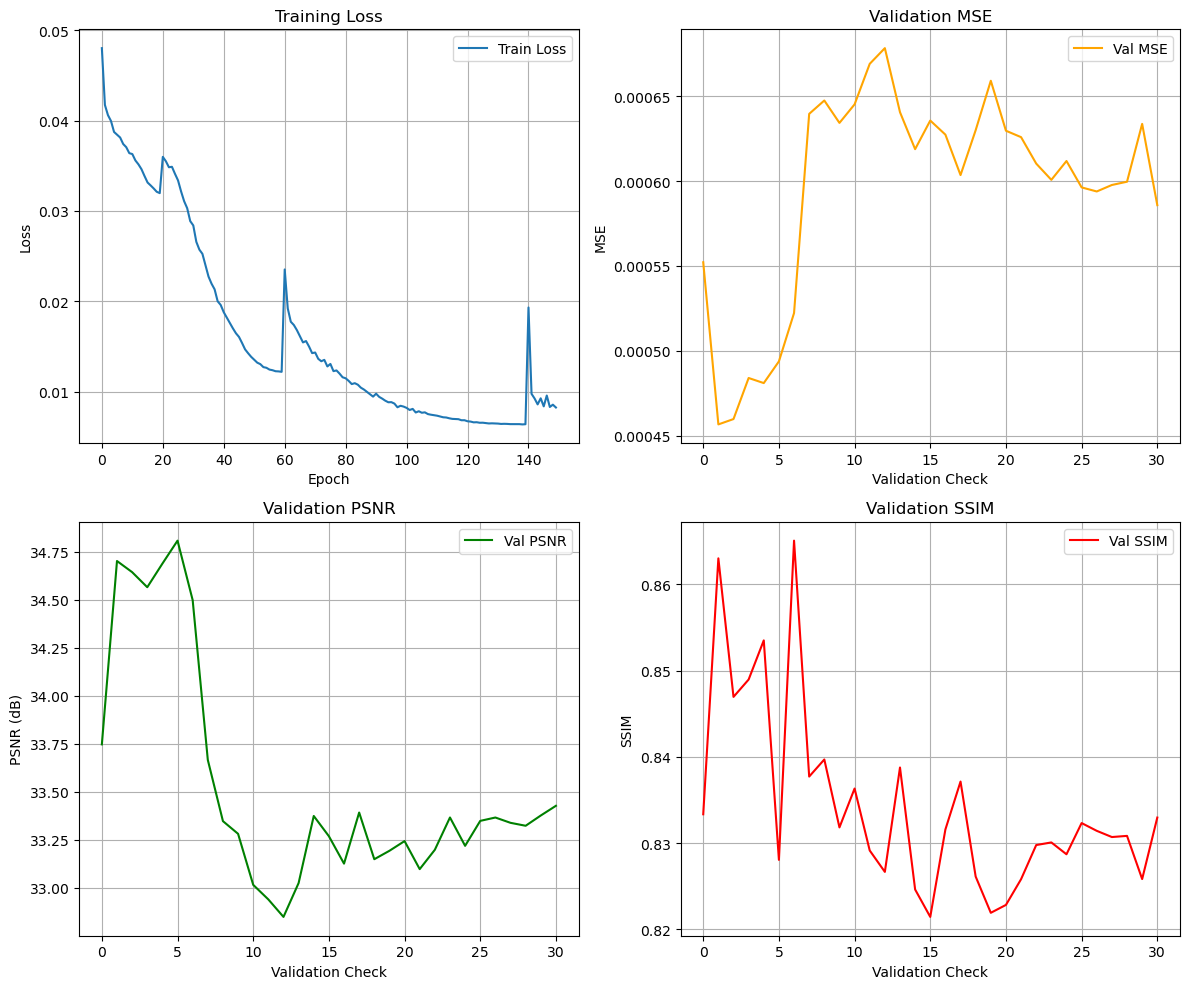

In [22]:
plot_training_history(history)


In [23]:
# Load best model
model.load_state_dict(best_model_state)

print("="*60)
print("FINAL EVALUATION - LIIF-EQ ON TEST SET")
print("="*60)

final_metrics = validate_gpu(model, test_loader, CONFIG['tranNum'])
print(f"MSE:  {final_metrics['mse']:.6f}")
print(f"PSNR: {final_metrics['psnr']:.2f} dB")
print(f"SSIM: {final_metrics['ssim']:.4f}")


FINAL EVALUATION - LIIF-EQ ON TEST SET


Validating: 100%|██████████| 30/30 [00:00<00:00, 117.68it/s]

MSE:  0.000494
PSNR: 34.81 dB
SSIM: 0.8281


In [25]:
@torch.no_grad()
def evaluate_per_image(model, test_pairs_dataset, device, tranNum):
    model.eval()
    results = []

    for i in range(len(test_pairs_dataset)):
        lr, hr = test_pairs_dataset[i]
        hr_shape = hr.shape[-2:]

        sr = super_resolve(model, lr, hr_shape, device, tranNum)

        sr_np = sr.numpy()
        hr_np = hr.numpy()

        if sr_np.ndim == 3 and sr_np.shape[0] == 1:
            sr_np = sr_np[0]
            hr_np = hr_np[0]

        mse_val = float(np.mean((sr_np - hr_np) ** 2))
        psnr_val = float(psnr(hr_np, sr_np, data_range=1.0))
        ssim_val = float(ssim(hr_np, sr_np, data_range=1.0))

        results.append({'image_idx': i, 'mse': mse_val, 'psnr': psnr_val, 'ssim': ssim_val})

    return results


print("="*70)
print("PER-IMAGE EVALUATION METRICS")
print("="*70)

per_image_results = evaluate_per_image(model, test_base, CONFIG['device'], CONFIG['tranNum'])

print(f"{'Image':<10} {'MSE':<15} {'PSNR (dB)':<15} {'SSIM':<15}")
print("-"*55)
for r in per_image_results:
    print(f"{r['image_idx']:<10} {r['mse']:<15.6f} {r['psnr']:<15.2f} {r['ssim']:<15.4f}")
print("-"*55)

# Summary statistics
psnr_values = [r['psnr'] for r in per_image_results]
ssim_values = [r['ssim'] for r in per_image_results]
print(f"PSNR - Mean: {np.mean(psnr_values):.2f} | Std: {np.std(psnr_values):.2f} | Min: {np.min(psnr_values):.2f} | Max: {np.max(psnr_values):.2f}")
print(f"SSIM - Mean: {np.mean(ssim_values):.4f} | Std: {np.std(ssim_values):.4f} | Min: {np.min(ssim_values):.4f} | Max: {np.max(ssim_values):.4f}")


PER-IMAGE EVALUATION METRICS
Image      MSE             PSNR (dB)       SSIM           
-------------------------------------------------------
0          0.000853        30.69           0.5791         
1          0.000331        34.81           0.8802         
2          0.000827        30.83           0.4077         
3          0.001594        27.98           0.5235         
4          0.000846        30.73           0.7092         
5          0.000623        32.05           0.7656         
6          0.001072        29.70           0.6709         
7          0.000079        41.01           0.9677         
8          0.000883        30.54           0.6247         
9          0.000216        36.66           0.8851         
10         0.001119        29.51           0.8834         
11         0.000214        36.70           0.9657         
12         0.000129        38.90           0.9631         
13         0.000429        33.68           0.9507         
14         0.000215        36.

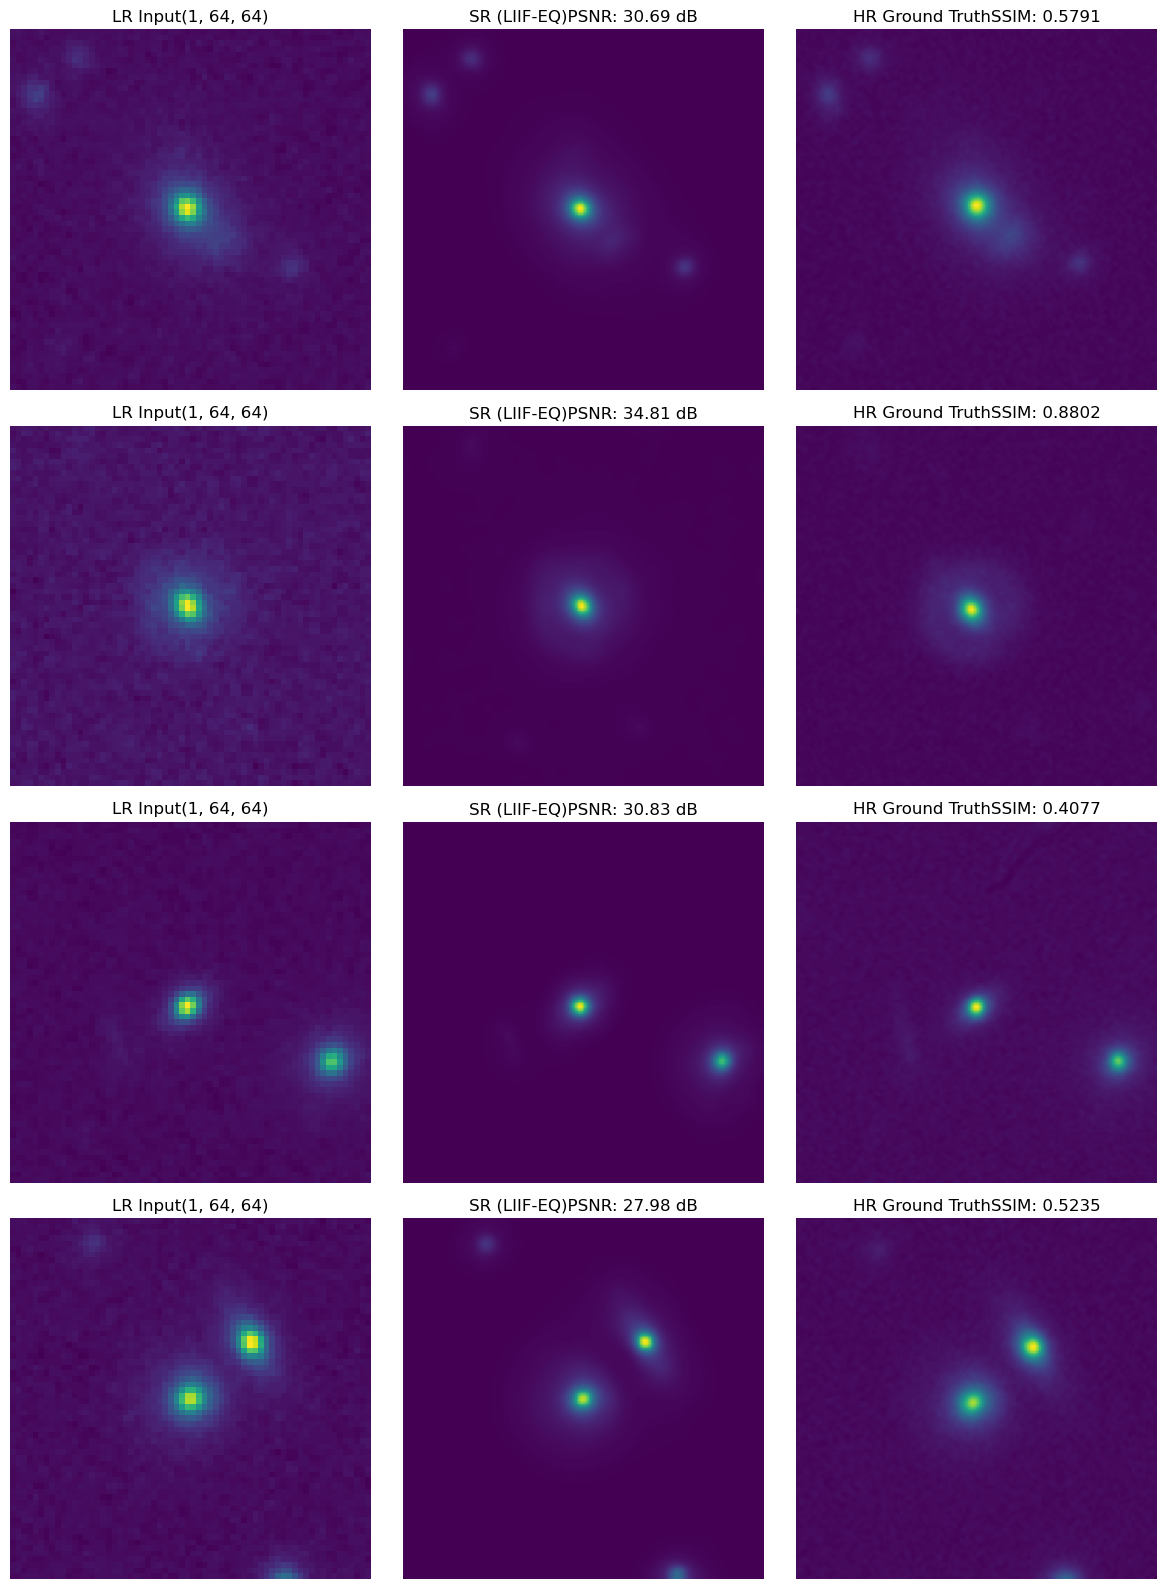

In [26]:
plot_results(model, test_dataset, CONFIG['device'], CONFIG['tranNum'], num_samples=4)


In [27]:
save_path = 'liif_eq_lensing_improved.pth'

torch.save({
    'model_state_dict': best_model_state,
    'config': CONFIG,
    'final_metrics': final_metrics,
    'history': history,
    'architecture': 'LIIF-EQ-Improved',
    'tranNum': CONFIG['tranNum'],
    'encoder_dim': CONFIG['encoder_dim'],
    'n_resblocks': CONFIG['n_resblocks'],
}, save_path)

print(f"Model saved to: {save_path}")
print(f"Final PSNR: {final_metrics['psnr']:.2f} dB")
print(f"Final SSIM: {final_metrics['ssim']:.4f}")


Model saved to: liif_eq_lensing_improved.pth
Final PSNR: 34.81 dB
Final SSIM: 0.8281
